
# Generador de señales discretas

Este notebook implementa funciones para generar señales discretas en el tiempo:
- Senoidal
- Cuadrada
- Triangular
- Diente de sierra
- Pulso

## Parámetros utilizados

- fs: frecuencia de muestreo [Hz]
- nn: cantidad de muestras
- ff: frecuencia de la señal [Hz]
- vmax: amplitud pico [V]
- dc: offset [V]
- ph: fase [rad]
- duty: duty cycle

# Ruido
- Generador de ruido gaussiano
- Senoidal + ruido en función de la SNR
- Cualquier señal + ruido en función de la SNR

In [59]:
import numpy as np

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * np.sin( 2*np.pi * ff * tt + ph )
    return tt, xx


def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, duty=0.5, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + np.where(((tt * ff + ph/(2*np.pi)) % 1) < duty, vmax, -vmax)
    return tt, xx


def mi_funcion_triangular(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * (2 * np.abs(2 * ((tt * ff + ph/(2*np.pi)) % 1) - 1) - 1)
    return tt, xx


def mi_funcion_diente_sierra(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * (2 * ((tt * ff + ph/(2*np.pi)) % 1) - 1)
    return tt, xx


def mi_funcion_pulso(vmax=1, dc=0, t0=0, ancho=1, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = dc + vmax * np.where((tt >= t0) & (tt <= t0 + ancho), 1, 0)
    return tt, xx


def mi_funcion_ruido(sigma=1, nn=1000, fs=1000):
    tt = np.arange(start = 0, stop = nn/fs, step = 1/fs)
    xx = np.random.normal(0, sigma, len(tt))
    return tt, xx


def mi_funcion_sen_con_ruido(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, snr_db=10):
    # Señal
    tt, xx_s = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    Ps = np.mean(xx_s**2)

    # Ruido
    snr_linear = 10**(snr_db / 10)
    Pn = Ps / snr_linear  # Potencia de ruido resultante
    xx_n = np.random.normal(0, np.sqrt(Pn), len(tt))

    xx = xx_s + xx_n

    return tt, xx, xx_s, xx_n


def mi_funcion_con_ruido(xx_s, tt_s, snr_db=10):
  Ps = np.mean(xx_s**2)
  snr_linear = 10**(snr_db / 10)

  Pn = Ps / snr_linear  # Potencia de ruido resultante
  xx_n = np.random.normal(0, np.sqrt(Pn), len(tt))

  xx = xx_s + xx_n

  return xx, xx_n

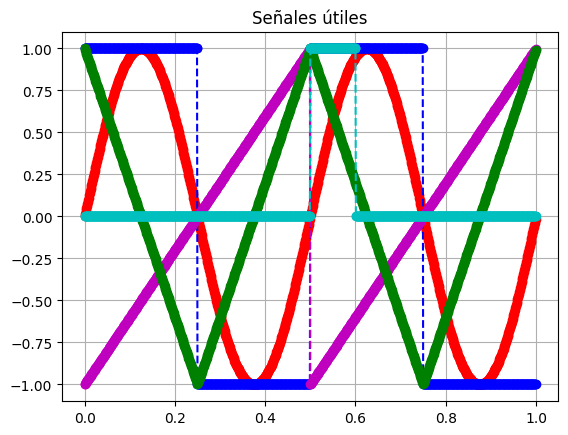

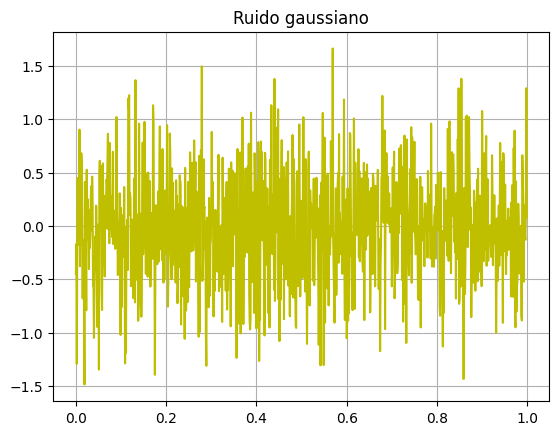

In [60]:
import matplotlib.pyplot as plt

# == Ejemplo de uso ===
# Parámetros de la simulación
fs = 1000 # Hz
N = fs  # Resolución espectral fs/N = 1Hz, tiempo de simulación 1seg

# Parámetros de las señales
fx = 2  # Hz
ax = 1  # V
dx = 0  # V
px = 0  # rad
duty = 0.5
t0x = 0.5  # seg
tfx = 0.1 # seg

# Generar señales
tt1, xx1 = mi_funcion_sen(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
tt2, xx2 = mi_funcion_cuadrada(vmax=ax, dc=dx, ff=fx, ph=px, duty=duty, nn=N, fs=fs)
tt3, xx3 = mi_funcion_diente_sierra(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
tt4, xx4 = mi_funcion_triangular(vmax=ax, dc=dx, ff=fx, ph=px, nn=N, fs=fs)
tt5, xx5 = mi_funcion_pulso(vmax=ax, dc=dx, t0=t0x, ancho=tfx, nn=N, fs=fs)
tt6, xx6 = mi_funcion_ruido(sigma=0.5, nn=N, fs=fs)

# Ploteo
plt.figure()
plt.plot(tt1, xx1, 'o--', color = 'r')
plt.plot(tt2, xx2, 'o--', color = 'b')
plt.plot(tt3, xx3, 'o--', color = 'm')
plt.plot(tt4, xx4, 'o--', color = 'g')
plt.plot(tt5, xx5, 'o--', color = 'c')
plt.title("Señales útiles")
plt.grid()
plt.show()

plt.figure()
plt.plot(tt6, xx6, '-', color = 'y')
plt.title("Ruido gaussiano")
plt.grid()
plt.show()

# Experimento con distintas frecuencias de señal, tasa de muestreo de 1000 Hz

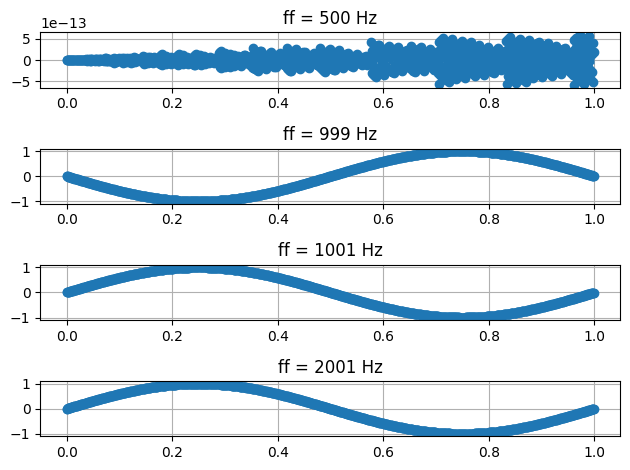

In [61]:
# Frecuencias a analizar
fx = [500, 999, 1001, 2001]

for i, f in enumerate(fx):
    tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=f, ph=0, nn=N, fs=fs)

    plt.subplot(len(fx), 1, i+1)
    plt.plot(tt, xx, 'o--')
    plt.title(f"ff = {f} Hz")
    plt.grid()

plt.tight_layout()
plt.show()

### Observaciones

- ff = 500 Hz → corresponde a fs/2 (frecuencia de Nyquist), aproximadamente 0 en todo el período.
- ff = 999 Hz → se ve como una senoidal de -1Hz o 1Hz con fase pi
- ff = 1001 Hz → senoidal de 1 Hz
- ff = 2001 Hz → senoidal de 1 Hz

Esto demuestra que señales con frecuencia mayor a fs/2 no pueden representarse correctamente por el aliasing.

# Senoidal ruidosa

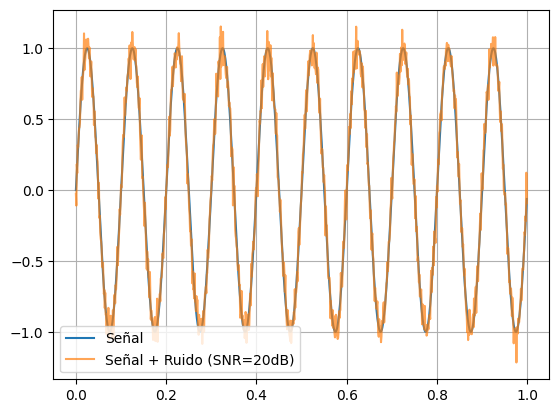

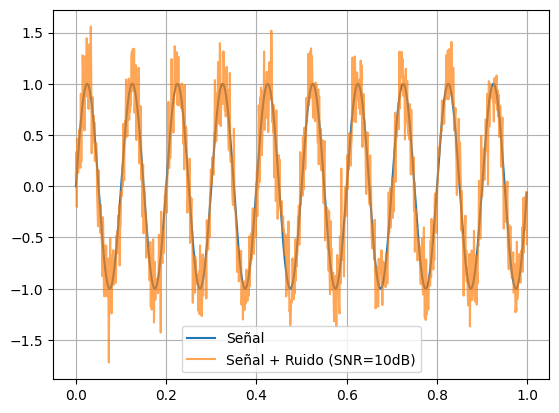

In [69]:
tt, x_total, x_s, x_n = mi_funcion_sen_con_ruido(vmax=1, ff=10, nn=N, fs=fs, snr_db=20)
x_total2, x_n2 = mi_funcion_con_ruido(x_s, tt, snr_db=10)

plt.figure()
plt.plot(tt, x_s, label="Señal")
plt.plot(tt, x_total, label="Señal + Ruido (SNR=20dB)", alpha=0.7)
plt.legend()
plt.grid()
plt.show()
plt.figure()

plt.plot(tt, x_s, label="Señal")
plt.plot(tt, x_total2, label="Señal + Ruido (SNR=10dB)", alpha=0.7)
plt.legend()
plt.grid()
plt.show()